In [1]:
# ============================================================
# Setup
# ============================================================
from google.colab import drive
drive.mount('/content/drive')

import sys, os
sys.path.insert(0, '/content/drive/MyDrive/brain_tumor_classification')

import torch
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['figure.dpi'] = 300

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device : {device}")
print(f"GPU    : {torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'None'}")
print("Setup complete.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Device : cuda
GPU    : Tesla T4
Setup complete.


In [2]:
# ============================================================
#  Verify config paths
#  Run this before any experiment to confirm paths are correct.
# ============================================================
from utils.config import get_default_config

cfg = get_default_config()

print("Config path check:")
print(f"  Project root  : {cfg.paths.root}")
print(f"  Data dir      : {cfg.paths.data_dir}")
print(f"  Experiments   : {cfg.paths.experiments_dir}")
print()

# Verify data folder exists and has images
for split in ['Training', 'Testing']:
    split_path = os.path.join(cfg.paths.data_dir, split)
    if os.path.exists(split_path):
        classes = os.listdir(split_path)
        print(f"  {split}/ found — {len(classes)} class folders")
    else:
        print(f"  ERROR: {split_path} not found!")
        print("  Check that your data_dir in config.py is correct.")

Config path check:
  Project root  : /content/drive/MyDrive/brain_tumor_classification
  Data dir      : /content/drive/MyDrive/brain_tumor_classification/data
  Experiments   : /content/drive/MyDrive/brain_tumor_classification/experiments

  Training/ found — 4 class folders
  Testing/ found — 4 class folders


In [3]:
# ============================================================
#  Experiment 1: EfficientNetB3 baseline
#  Expected time: ~30 minutes on Colab T4
# ============================================================
from utils.config import get_experiment_config
from src.train import main

print("=" * 52)
print("  Experiment 1 of 4 — EfficientNetB3 baseline")
print("=" * 52)

cfg1 = get_experiment_config(
    name     = "baseline_efficientnet_b3",
    backbone = "efficientnet_b3",
    dropout  = 0.3,
)

best_f1_effnet = main(config=cfg1)
print(f"\nExperiment 1 complete. Best Val F1: {best_f1_effnet:.4f}")

  Experiment 1 of 4 — EfficientNetB3 baseline
  Config saved → /content/drive/MyDrive/brain_tumor_classification/experiments/baseline_efficientnet_b3/config.yaml
2026-04-06 09:19:51 | INFO     | Log file: /content/drive/MyDrive/brain_tumor_classification/experiments/baseline_efficientnet_b3/baseline_efficientnet_b3_20260406_091951.log


INFO:baseline_efficientnet_b3:Log file: /content/drive/MyDrive/brain_tumor_classification/experiments/baseline_efficientnet_b3/baseline_efficientnet_b3_20260406_091951.log


2026-04-06 09:19:51 | INFO     | ====================================================


INFO:baseline_efficientnet_b3:====================================================


2026-04-06 09:19:51 | INFO     |   Experiment : baseline_efficientnet_b3


...

2026-04-06 10:12:03 | INFO     |   Metrics saved: /content/drive/MyDrive/brain_tumor_classification/experiments/baseline_efficientnet_b3/metrics.csv


INFO:baseline_efficientnet_b3:  Metrics saved: /content/drive/MyDrive/brain_tumor_classification/experiments/baseline_efficientnet_b3/metrics.csv


2026-04-06 10:12:03 | INFO     | ====================================================


INFO:baseline_efficientnet_b3:====================================================



Experiment 1 complete. Best Val F1: 0.9432


In [4]:
# ============================================================
#  Experiment 2: ResNet50 baseline
#  Expected time: ~30 minutes on Colab T4
# ============================================================
print("=" * 52)
print("  Experiment 2 of 4 — ResNet50 baseline")
print("=" * 52)

cfg2 = get_experiment_config(
    name     = "baseline_resnet50",
    backbone = "resnet50",
    dropout  = 0.3,
)

best_f1_resnet = main(config=cfg2)
print(f"\nExperiment 2 complete. Best Val F1: {best_f1_resnet:.4f}")

  Experiment 2 of 4 — ResNet50 baseline
  Config saved → /content/drive/MyDrive/brain_tumor_classification/experiments/baseline_resnet50/config.yaml
2026-04-06 10:12:58 | INFO     | Log file: /content/drive/MyDrive/brain_tumor_classification/experiments/baseline_resnet50/baseline_resnet50_20260406_101258.log


INFO:baseline_resnet50:Log file: /content/drive/MyDrive/brain_tumor_classification/experiments/baseline_resnet50/baseline_resnet50_20260406_101258.log


2026-04-06 10:12:58 | INFO     | ====================================================


INFO:baseline_resnet50:====================================================


2026-04-06 10:12:58 | INFO     |   Experiment : baseline_resnet50


...

2026-04-06 10:34:44 | INFO     |   Metrics saved: /content/drive/MyDrive/brain_tumor_classification/experiments/baseline_resnet50/metrics.csv


INFO:baseline_resnet50:  Metrics saved: /content/drive/MyDrive/brain_tumor_classification/experiments/baseline_resnet50/metrics.csv


2026-04-06 10:34:44 | INFO     | ====================================================


INFO:baseline_resnet50:====================================================



Experiment 2 complete. Best Val F1: 0.8957


In [5]:
# ============================================================
#  Experiment 3: DenseNet121 baseline
#  Expected time: ~20 minutes on Colab T4
# ============================================================
print("=" * 52)
print("  Experiment 3 of 4 — DenseNet121 baseline")
print("=" * 52)

cfg3 = get_experiment_config(
    name     = "baseline_densenet121",
    backbone = "densenet121",
    dropout  = 0.3,
)

best_f1_dense = main(config=cfg3)
print(f"\nExperiment 3 complete. Best Val F1: {best_f1_dense:.4f}")

  Experiment 3 of 4 — DenseNet121 baseline
  Config saved → /content/drive/MyDrive/brain_tumor_classification/experiments/baseline_densenet121/config.yaml
2026-04-06 10:36:45 | INFO     | Log file: /content/drive/MyDrive/brain_tumor_classification/experiments/baseline_densenet121/baseline_densenet121_20260406_103645.log


INFO:baseline_densenet121:Log file: /content/drive/MyDrive/brain_tumor_classification/experiments/baseline_densenet121/baseline_densenet121_20260406_103645.log


2026-04-06 10:36:45 | INFO     | ====================================================


INFO:baseline_densenet121:====================================================


2026-04-06 10:36:45 | INFO     |   Experiment : baseline_densenet121


...

2026-04-06 11:00:42 | INFO     |   Metrics saved: /content/drive/MyDrive/brain_tumor_classification/experiments/baseline_densenet121/metrics.csv


INFO:baseline_densenet121:  Metrics saved: /content/drive/MyDrive/brain_tumor_classification/experiments/baseline_densenet121/metrics.csv


2026-04-06 11:00:42 | INFO     | ====================================================


INFO:baseline_densenet121:====================================================



Experiment 3 complete. Best Val F1: 0.9689


In [6]:
# ============================================================
#  Experiment 4: VGG16 baseline
#  Expected time: ~50 minutes on Colab T4 (heaviest model)
# ============================================================
print("=" * 52)
print("  Experiment 4 of 4 — VGG16 baseline")
print("=" * 52)

cfg4 = get_experiment_config(
    name     = "baseline_vgg16",
    backbone = "vgg16",
    dropout  = 0.3,
)

best_f1_vgg = main(config=cfg4)
print(f"\nExperiment 4 complete. Best Val F1: {best_f1_vgg:.4f}")

  Experiment 4 of 4 — VGG16 baseline
  Config saved → /content/drive/MyDrive/brain_tumor_classification/experiments/baseline_vgg16/config.yaml
2026-04-06 11:00:58 | INFO     | Log file: /content/drive/MyDrive/brain_tumor_classification/experiments/baseline_vgg16/baseline_vgg16_20260406_110058.log


INFO:baseline_vgg16:Log file: /content/drive/MyDrive/brain_tumor_classification/experiments/baseline_vgg16/baseline_vgg16_20260406_110058.log


2026-04-06 11:00:58 | INFO     | ====================================================


INFO:baseline_vgg16:====================================================


2026-04-06 11:00:58 | INFO     |   Experiment : baseline_vgg16


...

2026-04-06 11:30:19 | INFO     |   Metrics saved: /content/drive/MyDrive/brain_tumor_classification/experiments/baseline_vgg16/metrics.csv


INFO:baseline_vgg16:  Metrics saved: /content/drive/MyDrive/brain_tumor_classification/experiments/baseline_vgg16/metrics.csv


2026-04-06 11:30:19 | INFO     | ====================================================


INFO:baseline_vgg16:====================================================



Experiment 4 complete. Best Val F1: 0.9795



  Baseline Experiment Results
          Model  Accuracy  Macro F1  Val Loss  Epoch
Efficientnet B3     94.29    0.9432    0.4909     29
       Resnet50     89.64    0.8957    0.5607     26
    Densenet121     96.88    0.9689    0.4308     30
          Vgg16     97.95    0.9795    0.3910     26

  Best backbone: Vgg16
  This backbone will be used for the ablation study.



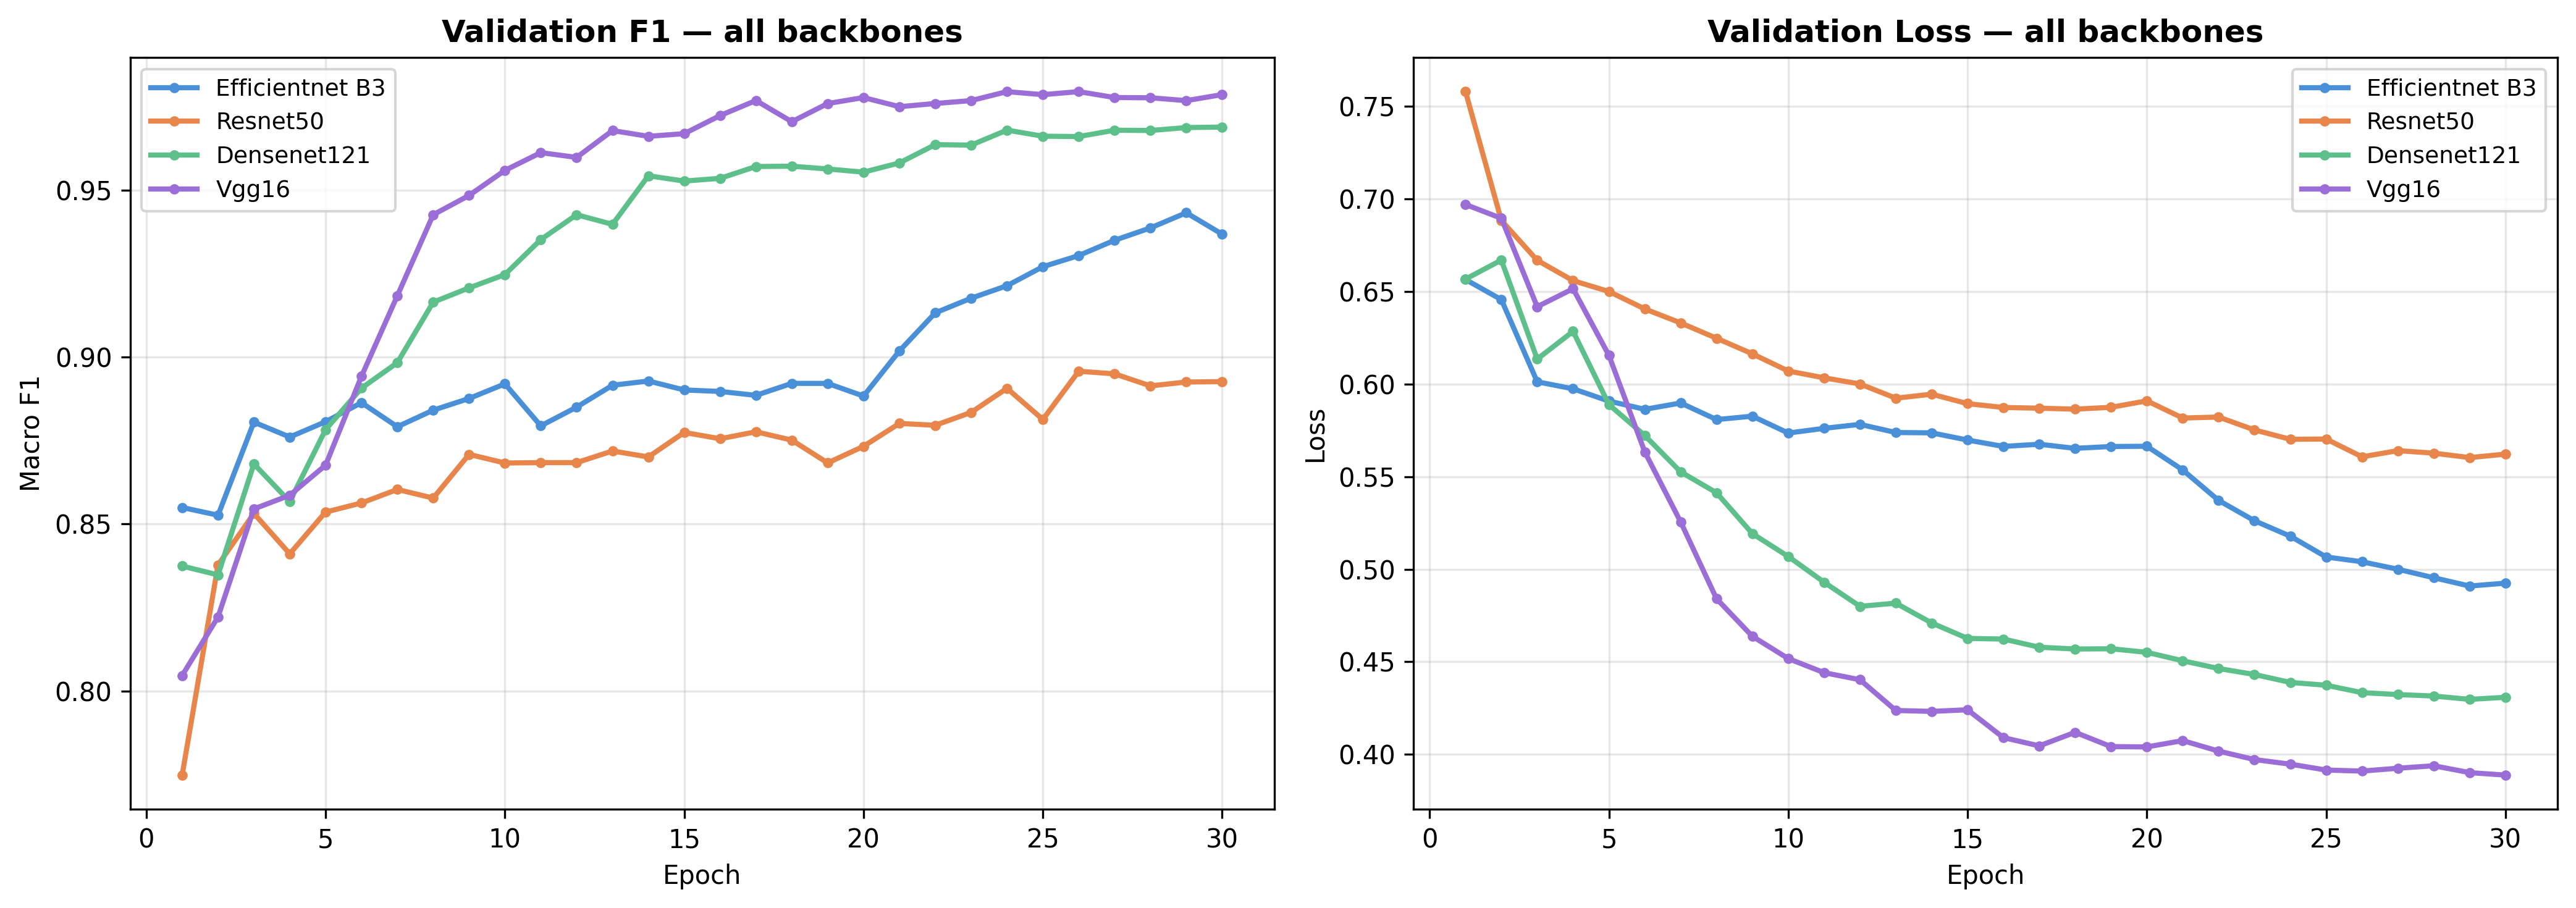

  Chart saved → outputs/baseline_comparison.png


In [7]:
# ============================================================
#  Compare all 4 baseline results
#  Run this after all 4 experiments are done.
#  Loads metrics.csv from each experiment folder.
# ============================================================
import pandas as pd
import matplotlib.pyplot as plt
import os

EXPERIMENTS_DIR = '/content/drive/MyDrive/brain_tumor_classification/experiments'
OUTPUTS_DIR     = '/content/drive/MyDrive/brain_tumor_classification/outputs'

baselines = [
    "baseline_efficientnet_b3",
    "baseline_resnet50",
    "baseline_densenet121",
    "baseline_vgg16",
]

# ── Load best val metrics from each experiment
results = []
for exp_name in baselines:
    csv_path = os.path.join(EXPERIMENTS_DIR, exp_name, "metrics.csv")
    if not os.path.exists(csv_path):
        print(f"  WARNING: {csv_path} not found — skipping")
        continue

    df  = pd.read_csv(csv_path)
    val = df[df["phase"] == "val"]
    best_row = val.loc[val["f1"].idxmax()]

    results.append({
        "Model":    exp_name.replace("baseline_", "").replace("_", " ").title(),
        "Accuracy": round(best_row["accuracy"] * 100, 2),
        "Macro F1": round(best_row["f1"], 4),
        "Val Loss": round(best_row["loss"], 4),
        "Epoch":    int(best_row["epoch"]),
    })

results_df = pd.DataFrame(results)

# ── Print comparison table
print("\n" + "=" * 62)
print("  Baseline Experiment Results")
print("=" * 62)
print(results_df.to_string(index=False))
print("=" * 62)

best_model = results_df.loc[results_df["Macro F1"].idxmax(), "Model"]
print(f"\n  Best backbone: {best_model}")
print(f"  This backbone will be used for the ablation study.\n")

# ── Plot: val F1 training curves for all 4 models
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
colors = ['#4A90D9', '#E8854A', '#5DBF8A', '#9B6DD6']

for i, exp_name in enumerate(baselines):
    csv_path = os.path.join(EXPERIMENTS_DIR, exp_name, "metrics.csv")
    if not os.path.exists(csv_path):
        continue

    df       = pd.read_csv(csv_path)
    val_data = df[df["phase"] == "val"]
    label    = exp_name.replace("baseline_", "").replace("_", " ").title()

    # Val F1 curve
    axes[0].plot(val_data["epoch"], val_data["f1"],
                 color=colors[i], linewidth=2, label=label, marker='o',
                 markersize=3)

    # Val Loss curve
    axes[1].plot(val_data["epoch"], val_data["loss"],
                 color=colors[i], linewidth=2, label=label, marker='o',
                 markersize=3)

axes[0].set_title("Validation F1 — all backbones", fontweight='bold')
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Macro F1")
axes[0].legend(fontsize=9)
axes[0].grid(alpha=0.3)

axes[1].set_title("Validation Loss — all backbones", fontweight='bold')
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Loss")
axes[1].legend(fontsize=9)
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(f'{OUTPUTS_DIR}/baseline_comparison.png', bbox_inches='tight', dpi=150)
plt.show()
print(f"  Chart saved → outputs/baseline_comparison.png")

In [8]:
# ============================================================
#  Ablation experiments
#  Run AFTER Cell 8. Update BEST_BACKBONE below first.
# ============================================================

# ── UPDATE THIS to your best backbone from Cell 8
BEST_BACKBONE = "efficientnet_b3"   # change if different

ablations = [
    {"name": "ablation_dropout_0",         "dropout": 0.0, "wd": 1e-4, "smooth": 0.1},
    {"name": "ablation_dropout_5",         "dropout": 0.5, "wd": 1e-4, "smooth": 0.1},
    {"name": "ablation_no_label_smooth",   "dropout": 0.3, "wd": 1e-4, "smooth": 0.0},
    {"name": "ablation_high_weight_decay", "dropout": 0.3, "wd": 1e-3, "smooth": 0.1},
]

ablation_results = {}

for i, abl in enumerate(ablations):
    print(f"\n{'='*52}")
    print(f"  Ablation {i+1}/{len(ablations)} — {abl['name']}")
    print(f"  dropout={abl['dropout']}  wd={abl['wd']}  smooth={abl['smooth']}")
    print(f"{'='*52}")

    cfg_abl = get_experiment_config(
        name         = abl["name"],
        backbone     = BEST_BACKBONE,
        dropout      = abl["dropout"],
        weight_decay = abl["wd"],
        label_smooth = abl["smooth"],
    )

    best_f1 = main(config=cfg_abl)
    ablation_results[abl["name"]] = best_f1
    print(f"  Done. Best Val F1: {best_f1:.4f}")

print("\nAll ablation experiments complete.")


  Ablation 1/4 — ablation_dropout_0
  dropout=0.0  wd=0.0001  smooth=0.1
  Config saved → /content/drive/MyDrive/brain_tumor_classification/experiments/ablation_dropout_0/config.yaml
2026-04-06 11:32:12 | INFO     | Log file: /content/drive/MyDrive/brain_tumor_classification/experiments/ablation_dropout_0/ablation_dropout_0_20260406_113212.log


INFO:ablation_dropout_0:Log file: /content/drive/MyDrive/brain_tumor_classification/experiments/ablation_dropout_0/ablation_dropout_0_20260406_113212.log


2026-04-06 11:32:12 | INFO     | ====================================================


INFO:ablation_dropout_0:====================================================


2026-04-06 11:32:12 | INFO     |   Experiment : ablation_dropout_0


...

2026-04-06 13:02:44 | INFO     |   Metrics saved: /content/drive/MyDrive/brain_tumor_classification/experiments/ablation_high_weight_decay/metrics.csv


INFO:ablation_high_weight_decay:  Metrics saved: /content/drive/MyDrive/brain_tumor_classification/experiments/ablation_high_weight_decay/metrics.csv


2026-04-06 13:02:44 | INFO     | ====================================================


INFO:ablation_high_weight_decay:====================================================


  Done. Best Val F1: 0.9457

All ablation experiments complete.


In [9]:
# ============================================================
#  Final results table (all experiments)
# ============================================================
all_experiments = baselines + [a["name"] for a in ablations]

all_results = []
for exp_name in all_experiments:
    csv_path = os.path.join(EXPERIMENTS_DIR, exp_name, "metrics.csv")
    if not os.path.exists(csv_path):
        continue

    # Load config to show settings
    cfg_path = os.path.join(EXPERIMENTS_DIR, exp_name, "config.yaml")
    with open(cfg_path) as f:
        import yaml
        exp_cfg = yaml.safe_load(f)

    df       = pd.read_csv(csv_path)
    val      = df[df["phase"] == "val"]
    best_row = val.loc[val["f1"].idxmax()]

    all_results.append({
        "Experiment":   exp_name,
        "Backbone":     exp_cfg["model"]["backbone"],
        "Dropout":      exp_cfg["regularization"]["dropout_rate"],
        "Label Smooth": exp_cfg["train"]["label_smoothing"],
        "Weight Decay": exp_cfg["train"]["weight_decay"],
        "Accuracy (%)": round(best_row["accuracy"] * 100, 2),
        "Macro F1":     round(best_row["f1"], 4),
        "Val Loss":     round(best_row["loss"], 4),
        "Best Epoch":   int(best_row["epoch"]),
    })

final_df = pd.DataFrame(all_results)

print("\n" + "=" * 80)
print("  Phase 3 — Complete Results Table")
print("=" * 80)
print(final_df.to_string(index=False))
print("=" * 80)

# Save to CSV for the paper
save_path = os.path.join(OUTPUTS_DIR, "phase3_results.csv")
final_df.to_csv(save_path, index=False)
print(f"\n  Full results saved → outputs/phase3_results.csv")


  Phase 3 — Complete Results Table
                Experiment        Backbone  Dropout  Label Smooth  Weight Decay  Accuracy (%)  Macro F1  Val Loss  Best Epoch
  baseline_efficientnet_b3 efficientnet_b3      0.3           0.1        0.0001         94.29    0.9432    0.4909          29
         baseline_resnet50        resnet50      0.3           0.1        0.0001         89.64    0.8957    0.5607          26
      baseline_densenet121     densenet121      0.3           0.1        0.0001         96.88    0.9689    0.4308          30
            baseline_vgg16           vgg16      0.3           0.1        0.0001         97.95    0.9795    0.3910          26
        ablation_dropout_0 efficientnet_b3      0.0           0.1        0.0001         95.54    0.9554    0.4719          30
        ablation_dropout_5 efficientnet_b3      0.5           0.1        0.0001         93.12    0.9316    0.5073          30
  ablation_no_label_smooth efficientnet_b3      0.3           0.0        0.0001   